In [11]:
# 01 EDA
# This notebook explores the rice leaf disease dataset by examining class distribution, sample images, and image resolution characteristics. The goal is to identify dataset imbalance and visual limitations before training the classification model.

In [12]:
# =========================
# CELL 1: IMPORTS
# =========================
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_DIR = Path("data/processed/train")
VAL_DIR = Path("data/processed/validation")

In [13]:
# =========================
# CELL 2: LOAD DATA
# =========================
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")

train_df["full_path"] = train_df["filepath"].apply(lambda p: os.path.join("..", p))
val_df["full_path"] = val_df["filepath"].apply(lambda p: os.path.join("..", p))

train_df = train_df[train_df["full_path"].apply(os.path.exists)].reset_index(drop=True)
val_df = val_df[val_df["full_path"].apply(os.path.exists)].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
train_df.head()

Train shape: (4106, 4)
Validation shape: (1027, 4)


,filepath,label,split,full_path
0,data/processed/train/BrownSpot/brown_spot434.jpg,BrownSpot,train,..\data/processed/train/BrownSpot/brown_spot43...
1,data/processed/train/leaf_blast/leaf_blast777.jpg,leaf_blast,train,..\data/processed/train/leaf_blast/leaf_blast7...
2,data/processed/train/rice_hispa/rice_hispa919.jpg,rice_hispa,train,..\data/processed/train/rice_hispa/rice_hispa9...
3,data/processed/train/rice_hispa/rice_hispa291.jpg,rice_hispa,train,..\data/processed/train/rice_hispa/rice_hispa2...
4,data/processed/train/BrownSpot/brown_spot90.jpg,BrownSpot,train,..\data/processed/train/BrownSpot/brown_spot90...


In [14]:
# =========================
# CELL 3: TRAIN-VALIDATION SPLIT TABLE
# =========================
split_table = (
    train_df["label"]
    .value_counts()
    .sort_index()
    .rename("Train Count")
    .to_frame()
    .join(
        val_df["label"]
        .value_counts()
        .sort_index()
        .rename("Validation Count"),
        how="outer",
    )
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "Class"})
)

split_table["Total"] = split_table["Train Count"] + split_table["Validation Count"]

print(split_table)
split_table

        label  Train Count  Validation Count  Total
0   BrownSpot         1184               296   1480
1     Healthy          313                78    391
2  leaf_blast         1440               361   1801
3  rice_hispa         1169               292   1461


,label,Train Count,Validation Count,Total
0,BrownSpot,1184,296,1480
1,Healthy,313,78,391
2,leaf_blast,1440,361,1801
3,rice_hispa,1169,292,1461


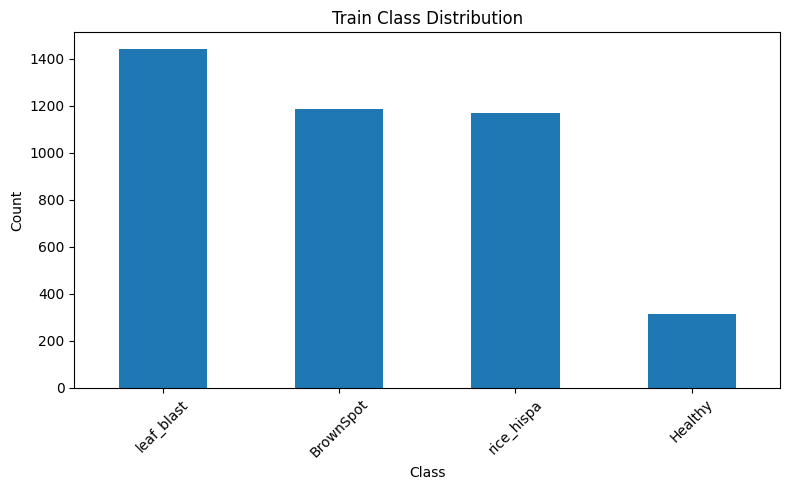

In [16]:
# =========================
# CELL 4: PLOT CLASS DISTRIBUTION
# =========================
class_counts = train_df["label"].value_counts()

if len(class_counts) == 0:
    print("No training data found. Check file paths.")
else:
    class_counts.plot(kind="bar", figsize=(8, 5), title="Train Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

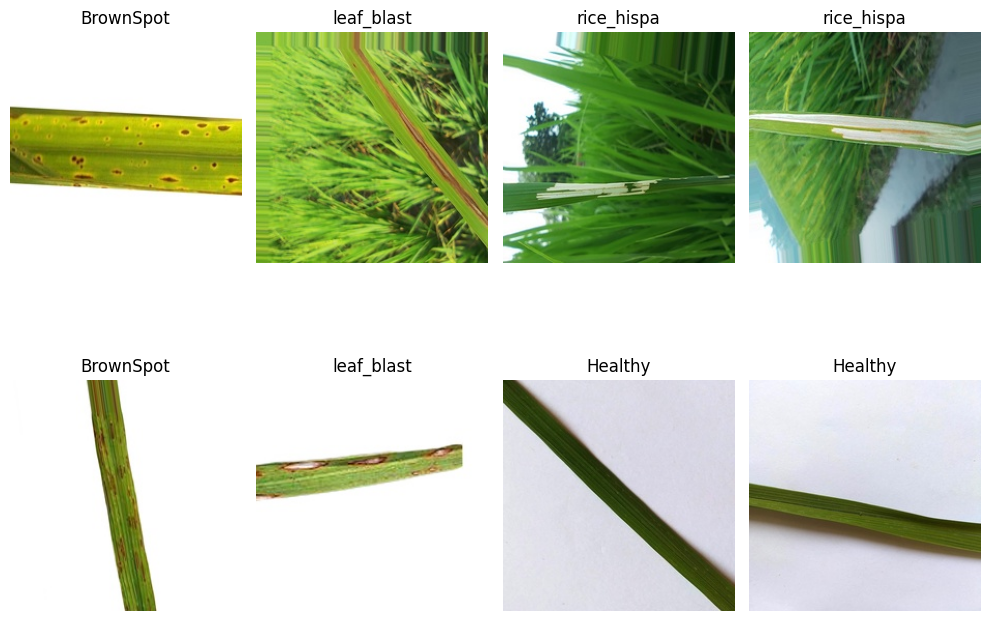

In [17]:
# =========================
# CELL 5: SHOW SAMPLE IMAGES
# =========================
sample_rows = train_df.groupby("label").head(2)

if len(sample_rows) == 0:
    print("No sample images found.")
else:
    plt.figure(figsize=(10, 8))
    for i, (_, row) in enumerate(sample_rows.iterrows(), start=1):
        img = Image.open(row["full_path"])
        plt.subplot(2, 4, i)
        plt.imshow(img)
        plt.title(row["label"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [18]:
# =========================
# CELL 6: IMAGE SIZE CHECK
# =========================
sizes = []

for path in train_df["full_path"].sample(min(100, len(train_df)), random_state=42):
    try:
        img = Image.open(path)
        sizes.append(img.size)
    except Exception:
        continue

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])
sizes_df.describe()

,width,height
count,100.0,100.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


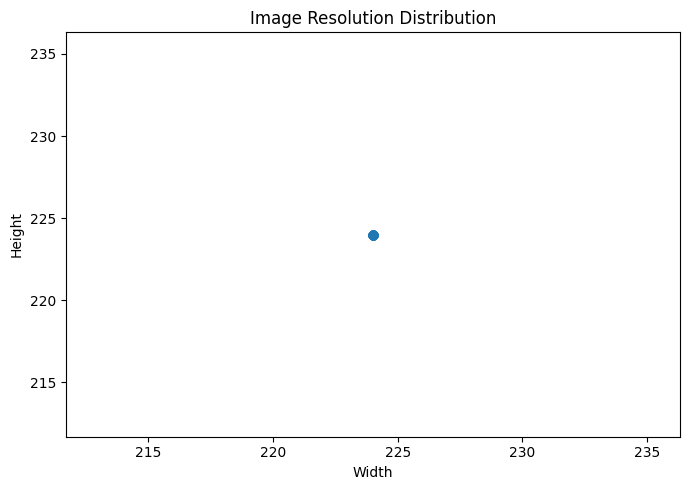

In [19]:
# =========================
# CELL 7: IMAGE SIZE DISTRIBUTION
# =========================
if len(sizes_df) == 0:
    print("No image sizes available.")
else:
    plt.figure(figsize=(7, 5))
    plt.scatter(sizes_df["width"], sizes_df["height"], alpha=0.6)
    plt.title("Image Resolution Distribution")
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.tight_layout()
    plt.show()